# Data Exploration Tutorial

In this notebook we explore the dataset of audio recordings collected and annotated by you.

You will learn how to:
- Set up an environment
- Load and inspect metadata and annotations using **pandas**
- Explore audio features
- Load and inspect raw audio with **librosa**

## 1. Environment Setup (5 minutes)

**Set up your conda environment:**

Before we start, create a dedicated conda environment. If you did not do so yet, download and install [miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install). Restart your terminal and run the following commands:

```bash
# 1. Create a new conda environment 'mlpc2026' with Python 3.12
conda create -y -n mlpc2026 -c conda-forge python=3.12 numpy pandas matplotlib jupyterlab librosa

# 2. Activate the environment
conda activate mlpc2026
```

Activate the conda environment via `conda activate mlpc2026`.
Start jupyterhub via `python -m jupyterlab`.

**Tips:** 
- Always use a dedicated environment per project to avoid dependency conflicts. 
- If you want to perform clustering or dimensionality reduction, we recommend installing `scikit-learn` as well.

**Run the cell below** to check your setup.

In [4]:
import os
import math

# if you've setup your environment, importing these libraries should not throw an error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH_TO_DATASET = os.path.join("..", "data", "MLPC2026_dataset_development")

assert os.path.exists(PATH_TO_DATASET), "The dataset folder 'MLPC2026_dataset' does not exist; download the data set and extract its content."
assert os.path.exists(os.path.join(PATH_TO_DATASET, 'annotations.csv')), "The file 'MLPC2026_dataset/annotations.csv' does not exist."
assert os.path.exists(os.path.join(PATH_TO_DATASET, 'metadata.csv')), "The file 'MLPC2026_dataset/metadata.csv' does not exist."
assert os.path.exists(os.path.join(PATH_TO_DATASET, 'audio_features')), "The folder 'MLPC2026_dataset/audio_featues' does not exist."

### Python Packages used

- [Pandas](https://pandas.pydata.org/docs/) for dealing with tabular data
- [Numpy](https://numpy.org/doc/stable/) for features
- [Matplotlib](https://matplotlib.org/stable/users/index.html) for plotting
- [Librosa](https://librosa.org/) for dealing with (raw) audio

## 2. Dataset Description

The dataset was **recorded and annotated by you** during the lab sessions.

### Folder structure

```
MLPC2026_dataset_development.zip
|-- metadata.csv
|-- annotations.csv
\-- audio_features/
    |-- 000001.npz
    |-- 000002.npz
    \-- ...
```

- ```metadata.csv``` contains metadata information about each file.
- ```annotations.csv``` contains the label annotations and their regions (onsets + offsets).
- ```audio_features/``` contains the precomputed audio features.

We also provide an additional zip archive containing the raw audio files, should you wish to use them.

### Key concepts

| Term | Meaning |
|---|---|
| **Sound event** | A temporal segment where a specific sound occurs |
| **Onset / Offset** | Start / end time (in seconds) of a sound event |
| **Class / Label** | Class name of the sound event (e.g. *"footsteps"*, *"coffee_machine"*) |
| **Feature** | a value or set of values extracted from audio that helps represent an audio characteristic |


## 3. Loading the Metadata

We can use **pandas** to load the CSV and explore it.

In [5]:
# Load the metadata csv
metadata = pd.read_csv(os.path.join(PATH_TO_DATASET, "metadata.csv"))
metadata[["filename", "target_classes", "recording_device", "scene_description"]].head(n=3)

,filename,target_classes,recording_device,scene_description
0,003075.wav,keyboard_typing;keychain,IPhone Xr,I was working on my laptop and playing with ke...
1,001117.wav,footsteps,Iphone 15 Pro,"I was walking and recorded a bird singing, car..."
2,001982.wav,footsteps;door_open_close;cutlery_dishes,Surface Pro 8,I went to the patio door and opened it. I went...


```pd.read_csv(PATH_TO_FILE)``` gives us a ```pd.DataFrame``` where individual columns are ```pd.Series```. The leftmost column gives the index to make the rows uniquely identifiable. The header at the top gives the name of the column. 

We can directly select the columns that are of interest by using ```metadata[LIST_OF_COLUMNS]```; ```.head(n=3)``` selects the first three rows of the table.

### Setting a new index

You can also change the unique row identifier (or index). We can set ```filename``` as our new index by using ```metadata.set_index("filename", inplace=True)```. 

This allows us to select rows based on the filename instead of the index.

In [6]:
# Set index to filename
metadata.set_index("filename", inplace=True)
metadata[["target_classes", "recording_device", "scene_description"]].head(n=3)

,target_classes,recording_device,scene_description
filename,,,
003075.wav,keyboard_typing;keychain,IPhone Xr,I was working on my laptop and playing with ke...
001117.wav,footsteps,Iphone 15 Pro,"I was walking and recorded a bird singing, car..."
001982.wav,footsteps;door_open_close;cutlery_dishes,Surface Pro 8,I went to the patio door and opened it. I went...


### Basic table properties

In [7]:
# Shape of data frame
print("DataFrame shape: \t", metadata.shape)
print("DataFrame rows: \t", len(metadata.index))
print("DataFrame columns: \t", len(metadata.columns))
print("DataFrame column names: \n", metadata.columns.to_list())

DataFrame shape: 	 (3656, 8)
DataFrame rows: 	 3656
DataFrame columns: 	 8
DataFrame column names: 
 ['target_classes', 'recording_device', 'device_placement', 'recording_environment', 'scene_description', 'license', 'collector_id', 'non_target_classes']


### Select columns

To select a single column, use the square brackets (as you would do for dictionaries).

In [8]:
# Select a column
print(metadata["target_classes"].head(n=3))
print(metadata.loc[:, "target_classes"].head(n=3))

filename
003075.wav                    keyboard_typing;keychain
001117.wav                                   footsteps
001982.wav    footsteps;door_open_close;cutlery_dishes
Name: target_classes, dtype: str
filename
003075.wav                    keyboard_typing;keychain
001117.wav                                   footsteps
001982.wav    footsteps;door_open_close;cutlery_dishes
Name: target_classes, dtype: str


The result is a ```pd.Series``` object. You can also use ```.loc[ROWS, COLUMNS]``` for a more fine-grained selection. ```:``` selects everything in the corresponding dimension.

To select multiple columns, provide a list of column names:

In [9]:
# Select multiple columns
print(metadata[["target_classes", "recording_environment"]].head(n=3))
print(metadata.loc[:, ["target_classes", "recording_environment"]].head(n=3))

                                      target_classes recording_environment
filename                                                                  
003075.wav                  keyboard_typing;keychain                office
001117.wav                                 footsteps                office
001982.wav  footsteps;door_open_close;cutlery_dishes           living_room
                                      target_classes recording_environment
filename                                                                  
003075.wav                  keyboard_typing;keychain                office
001117.wav                                 footsteps                office
001982.wav  footsteps;door_open_close;cutlery_dishes           living_room


Now the result is a ```pd.DataFrame``` object. Similar to the single column case, we can use ```.loc``` for a more detailed selection.

### Select rows

To select a row with an index (now: filename), we have to use ```.loc```:

In [10]:
metadata.loc["005490.wav"]

target_classes                                 footsteps;window_open_close
recording_device                                         iPhone 13 Pro Max
device_placement                                                    mobile
recording_environment                                          living_room
scene_description        I stood at the cabinet and opened a drawer to ...
license                  CC-BY 4.0 (Attribution License), Author: Xhona...
collector_id                                              0a7fded0819fc9e2
non_target_classes                                     snoring;phone_alarm
Name: 005490.wav, dtype: str

The result once more is a ```pd.Series``` object.

To select multiple rows instead, use ```.loc``` with a list of indices:

In [11]:
metadata.loc[["005490.wav", "005491.wav"], ["target_classes", "recording_device"]]

,target_classes,recording_device
filename,,
005490.wav,footsteps;window_open_close,iPhone 13 Pro Max
005491.wav,door_open_close;footsteps;cutlery_dishes;bell_...,iPhone 13 Pro Max


The result now is a ```pd.DataFrame``` object.

### Slices

You can also select multiple rows/columns using the <a href="https://stackoverflow.com/questions/509211/how-slicing-in-python-works">slicing</a> notation in python:

In [12]:
metadata.loc[::2, ["target_classes", "recording_device"]].head(n=3)

,target_classes,recording_device
filename,,
003075.wav,keyboard_typing;keychain,IPhone Xr
001982.wav,footsteps;door_open_close;cutlery_dishes,Surface Pro 8
002291.wav,light_switch;footsteps,Iphone 15 pro


Recap on the syntax: ```a[start:stop:step]```, so the slice ```::2``` select every second element (row) in this case. Note that the ```stop``` value represents the first value that is **not** in the selected slice.

### Selection based on condition

Quite often, we would like to select rows based on a condition. To do so, use an elementwise comparison and create a Series with True/False values:

In [13]:
(metadata["recording_environment"] == "kitchen").head(n=3)

filename
003075.wav    False
001117.wav    False
001982.wav    False
Name: recording_environment, dtype: bool

The result here maps filenames to True/False values. We can then use this sequence (aligned to our dataframe) and select all rows for which the condition is True:

In [14]:
metadata.loc[metadata["recording_environment"] == "kitchen"]

,target_classes,recording_device,device_placement,recording_environment,scene_description,license,collector_id,non_target_classes
filename,,,,,,,,
005594.wav,running_water;cutlery_dishes,Iphone 15 Pro,static,kitchen,I stand at the kitchen sink and turn on the wa...,CC0 (Public Domain Dedication),f9b9b8bbf3ef8ceb,fridge_noise
001690.wav,cutlery_dishes;running_water;coffee_machine,Huawei P20 Pro,static,kitchen,"I was making coffee, while washing dishes. The...",CC0 (Public Domain Dedication),b2b28a96c509f8ae,dishwasher_noise
004622.wav,cutlery_dishes;phone_ringing,motorola edge 30,static,kitchen,I unloaded dishes and cutlery in the kitchen. ...,CC0 (Public Domain Dedication),3f8613e65e335f2c,NaN
001386.wav,coffee_machine;wardrobe_drawer_open_close;cutl...,iPhone 14 Pro,static,kitchen,I turned on my coffee machine before opening m...,CC0 (Public Domain Dedication),4001ffe56d99b626,coffee_machine_beeping
001064.wav,light_switch;footsteps;cutlery_dishes,motorola_edge_40_neo,mobile,kitchen,"I actuate the light switch, then i went to the...",CC0 (Public Domain Dedication),0f38b3343bdaf813,NaN
...,...,...,...,...,...,...,...,...
001508.wav,coffee_machine;wardrobe_drawer_open_close;cutl...,iPhone 12,static,kitchen,I started the coffee machine and opened a kitc...,CC0 (Public Domain Dedication),7098caa5b9a6f4ca,NaN
002988.wav,window_open_close;cutlery_dishes,Iphone 14 Pro Max,mobile,kitchen,I opened the kitchen window and then closed it...,CC0 (Public Domain Dedication),4f95052700e25282,clothing_rustle
001026.wav,vacuum_cleaner;running_water;cutlery_dishes;mi...,iPhone 12,static,kitchen,"I turned the vacuum, running water, arranged m...",CC0 (Public Domain Dedication),7fbd9c7497d966de,NaN


### Basic statistics

We might also want to check at some point, whether we did not record too many files in one single recording environment. We can check how many records we did collect in each environment by using ```.value_counts()```, which gets us a series with counts of unique values:

In [15]:
rec_env_counts = metadata["recording_environment"].value_counts()
rec_env_counts.head(n=3)

recording_environment
kitchen        962
bedroom        585
living_room    424
Name: count, dtype: int64

The result is a ```pd.Series``` where the index is determined by the unique column values -- in this case ```kitchen```, ```hallway```, ```living_room```.

With these counts, we can compute some simple summary statistics:

In [16]:
print("Min: ", rec_env_counts.min())
print("Max: ", rec_env_counts.max())
print("Mean: ", rec_env_counts.mean())
print("Median: ", rec_env_counts.median())

Min:  1
Max:  962
Mean:  29.723577235772357
Median:  1.0


Or we can plot the distribution of recording environment counts. 

To plot the distribution of values, we can use the ```matplotlib``` library and ```.plot.hist(bins=n_bins, figsize=(width, height))```:

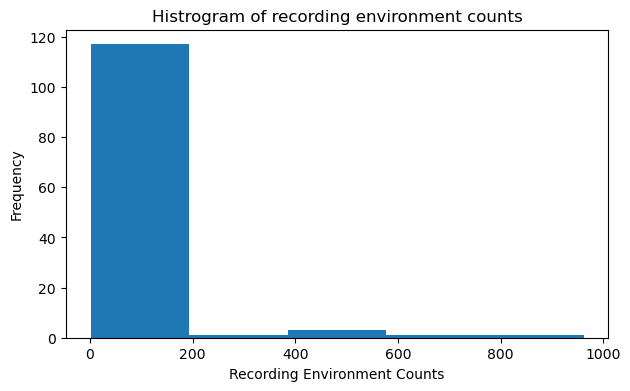

In [17]:
plt.title("Histrogram of recording environment counts")
rec_env_counts.plot.hist(bins=5, figsize=(7, 4))
plt.xlabel("Recording Environment Counts")
plt.show()

You can use the following commands to tweak your plot: 

- `plt.title(TITLE)` to add a title
- `plt.xlabel(X_LABEL)` to add a label for the horizontal axis
- `plt.ylabel(Y_LABEL)` to add a label for the vertical axis
- `plt.xticks(LIST_OF_INDICES, LIST_OF_DISPLAYED_NAMES_IN_PLOT)` to change the default ticks on the x axis

### Column transformation

Quite often, we want to introduce new columns based on values in another column. 

To create a new column based on an existing one, we can use the method ```.transform(function)```. Let's create a new column that is True if one of the target classes is related to or involves water:

In [18]:
def is_water(target_classes: str):
    return 'water' in target_classes or 'toilet' in target_classes or 'coffee' in target_classes

metadata["involves_water"] = metadata["target_classes"].transform(is_water)
metadata["involves_water"].value_counts()

involves_water
False    2410
True     1246
Name: count, dtype: int64

In [19]:
metadata.loc[metadata["involves_water"] == True, ["target_classes", "recording_environment"]]

,target_classes,recording_environment
filename,,
003018.wav,footsteps;toilet_flushing;running_water,bathroom
002419.wav,footsteps;running_water,kitchen;living_room
005594.wav,running_water;cutlery_dishes,kitchen
001690.wav,cutlery_dishes;running_water;coffee_machine,kitchen
001386.wav,coffee_machine;wardrobe_drawer_open_close;cutl...,kitchen
...,...,...
001628.wav,toilet_flushing;door_open_close;running_water,toilet;bathroom
001642.wav,door_open_close;running_water;toilet_flushing,toilet
001026.wav,vacuum_cleaner;running_water;cutlery_dishes;mi...,kitchen


## 4. Loading Annotations

You can load the annotations in the same way as the metadata, i.e.:

In [20]:
annotations = pd.read_csv(os.path.join(PATH_TO_DATASET, "annotations.csv"))
annotations[["filename", "annotator_id", "onset", "offset", "annotation", "is_own_recording"]].head(n=3)

,filename,annotator_id,onset,offset,annotation,is_own_recording
0,000112.wav,2190518039615423109192646528977018723001939610...,13.060211,13.315831,footsteps,False
1,000695.wav,4496809211053681637690999252976315563042618669...,1.508440,2.061877,door_open_close,False
2,000488.wav,7535443191697509271271535104115945129183028445...,4.833705,25.929958,microwave,True


### Basic table properties

In [21]:
print("DataFrame shape: ", annotations.shape)
print("DataFrame rows: ", len(annotations.index))
print("DataFrame columns: ", len(annotations.columns))
print("DataFrame column names: ", annotations.columns.to_list())

DataFrame shape:  (37419, 6)
DataFrame rows:  37419
DataFrame columns:  6
DataFrame column names:  ['filename', 'annotator_id', 'annotation', 'onset', 'offset', 'is_own_recording']


### Annotation counts and durations

We can also count the number of annotations per file using `.value_counts()` and apply some simple summary statistics. 

In [22]:
annotations_per_file = annotations["filename"].value_counts()

print("Min: ", annotations_per_file.min())
print("Max: ", annotations_per_file.max())
print("Mean: ", annotations_per_file.mean())
print("Median: ", annotations_per_file.median())

Min:  1
Max:  57
Mean:  10.234956236323852
Median:  9.0


Or we can plot the distribution of annotations per file:

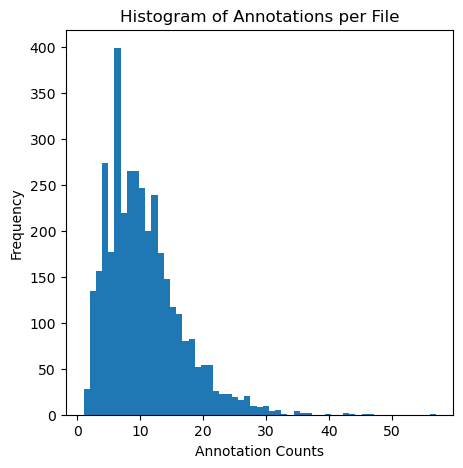

In [23]:
plt.title("Histogram of Annotations per File")
annotations_per_file.plot.hist(bins=annotations_per_file.max(), figsize=(5, 5))
plt.xlabel("Annotation Counts")
plt.show()

It might be also of interest to look at the length of the annotated segments. We can compute this by subtracting the onset from the offset time for each annotation. 
Let's add a new column to the annotations data frame that contains the segment length in seconds.

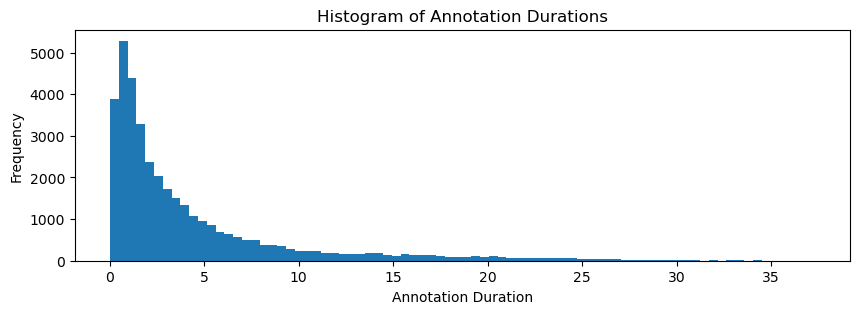

In [24]:
annotations["duration"] = annotations["offset"] - annotations["onset"]
annotations["duration"].plot.hist(bins=80, figsize=(10, 3))
plt.xlabel("Annotation Duration")
plt.ylabel("Frequency")
plt.title("Histogram of Annotation Durations")
plt.show()

### Grouping

Quite often, we're interested in comparing statistics for different groups. 

We can group the table by distinct values in a column using `.groupby(COLUMN_NAME)`and compute statistics for each group. Next, we compute the median annotation duration for each annotator:

In [25]:
median_duration_per_annotator = annotations.groupby("annotator_id")["duration"].median()
median_duration_per_annotator.head(n=3)

annotator_id
286330067860903610926652848251538243869553344779428654848421259154987376120     3.212190
669936843148118619610190209644570583933302008086303737800427934294007922362     1.233410
1119408104570139724301764673543749248915039488587866599424462987734777928999    3.594895
Name: duration, dtype: float64

### Merging two Tables

We might want to concatenate the recording environment associated with each audio file (in `metadata`) to the annotations.

In [26]:
metadata[["recording_environment"]].head(3)

,recording_environment
filename,
003075.wav,office
001117.wav,office
001982.wav,living_room


We can use ```merge``` for this as follows:

In [27]:
annotations_meta = annotations.merge(metadata, on="filename", how="left", suffixes=('', '_metadata'))
annotations_meta[["filename", "duration", "annotation", "recording_environment"]].head(n=3)

,filename,duration,annotation,recording_environment
0,000112.wav,0.255620,footsteps,living_room;kitchen
1,000695.wav,0.553437,door_open_close,room
2,000488.wav,21.096254,microwave,kitchen


- We use the `on` parameter as column to join on. 
- The `suffix` parameter is used to handle column name collisions when merging two DataFrames with overlapping column names.
- The parameter `how` specifies how to merge. Merging dataframes is similar to performing SQL joins.

## 5. Audio Features

The dataset package includes precomputed features and annotations that are already aggregated over one second windows with a hop size of 0.5 seconds. You may want to directly use the aligned annotation array.

```
MLPC2026_dataset_development.zip
|-- metadata.csv
|-- annotations.csv
\-- audio_features/       <-- load this
    |-- 000001.npz
    |-- 000002.npz
    \-- ...
```

Load the feature-annotation files with:

In [28]:
import os
import numpy as np

features_dir = os.path.join(PATH_TO_DATASET, "audio_features")
npz_files = sorted(
    [f for f in os.listdir(features_dir) if f.endswith(".npz")]
 )

print(f"Found {len(npz_files)} feature files in {features_dir}")
print("First 5 files:", npz_files[:5])

# Map from stem (e.g., '000001') to absolute file path for quick lookup
feature_file_map = {
    os.path.splitext(filename)[0]: os.path.join(features_dir, filename)
    for filename in npz_files
}

def load_feature_file(file_id: str):
    """Lazy-load a single .npz file by ID (without .npz extension)."""
    path = feature_file_map[file_id]
    return np.load(path, allow_pickle=True)

# Example: only this file is loaded now
example_file_id = next(iter(feature_file_map))
example_features = load_feature_file(example_file_id)

Found 3656 feature files in ../data/MLPC2026_dataset_development/audio_features
First 5 files: ['000001.npz', '000002.npz', '000003.npz', '000004.npz', '000005.npz']


The result is a dictionary holding the features and labels as numpy arrays:

In [29]:
example_features = dict(example_features)
example_features.keys() #, example_features

dict_keys(['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', 'non_target_classes'

In [30]:
example_features["annotations"].shape # [T, C, A]

(61, 15, 2)

## 6. Annotation Visualizations

The `annotations` array in each `.npz` file has shape **[T, C, A]** - time steps $\times$ classes $\times$ annotators. Each value represents the proportional overlap between an annotation event and the corresponding time segment.

Below we compare how different annotators labelled the same recording using image plots (one per annotator).

In [31]:
file_iterator = iter(feature_file_map)

(61, 15, 2)


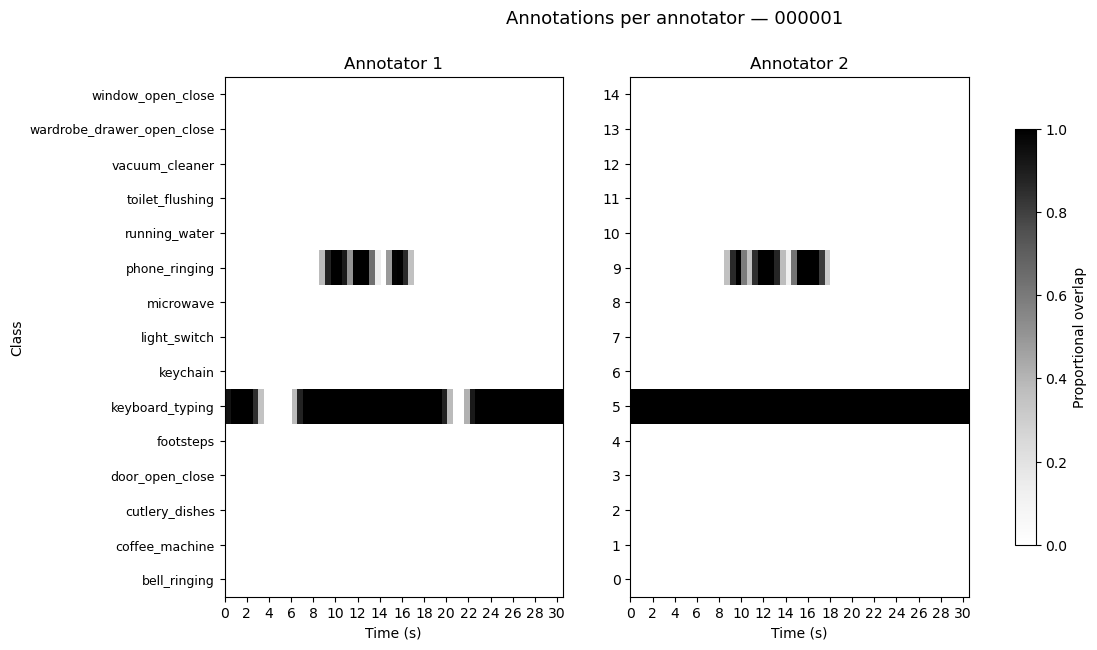

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# iterator
example_file_id = next(file_iterator)


# Load annotations for the example file
data = dict(load_feature_file(example_file_id))
ann = data["annotations"]          # shape: [T, C, A]
T, C, A = ann.shape
print(ann.shape)

# Class names
class_names = sorted(annotations["annotation"].unique().tolist())
if len(class_names) != C:
    class_names = [f"Class {i}" for i in range(C)]

# Time axis in seconds (0.5 s hop size)
hop = 0.5

# Plot one image per annotator side by side
fig, axes = plt.subplots(
    1, A,
    figsize=(6 * A, max(3, C * 0.45))
)
if A == 1:
    axes = [axes]

for a_idx, ax in enumerate(axes):
    im = ax.imshow(
        ann[:, :, a_idx].T,          # shape [C, T] for imshow
        aspect="auto",
        origin="lower",
        vmin=0, vmax=1,
        cmap="Greys",
        extent=[0, T * hop, -0.5, C - 0.5],
    )
    ax.set_title(f"Annotator {a_idx + 1}", fontsize=12)
    ax.set_xlabel("Time (s)")
    ax.set_yticks(range(C))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))

axes[0].set_yticklabels(class_names, fontsize=9)
axes[0].set_ylabel("Class")

cbar = fig.colorbar(im, ax=axes, shrink=0.8, label="Proportional overlap")
fig.suptitle(f"Annotations per annotator — {example_file_id}", fontsize=13)
plt.show()

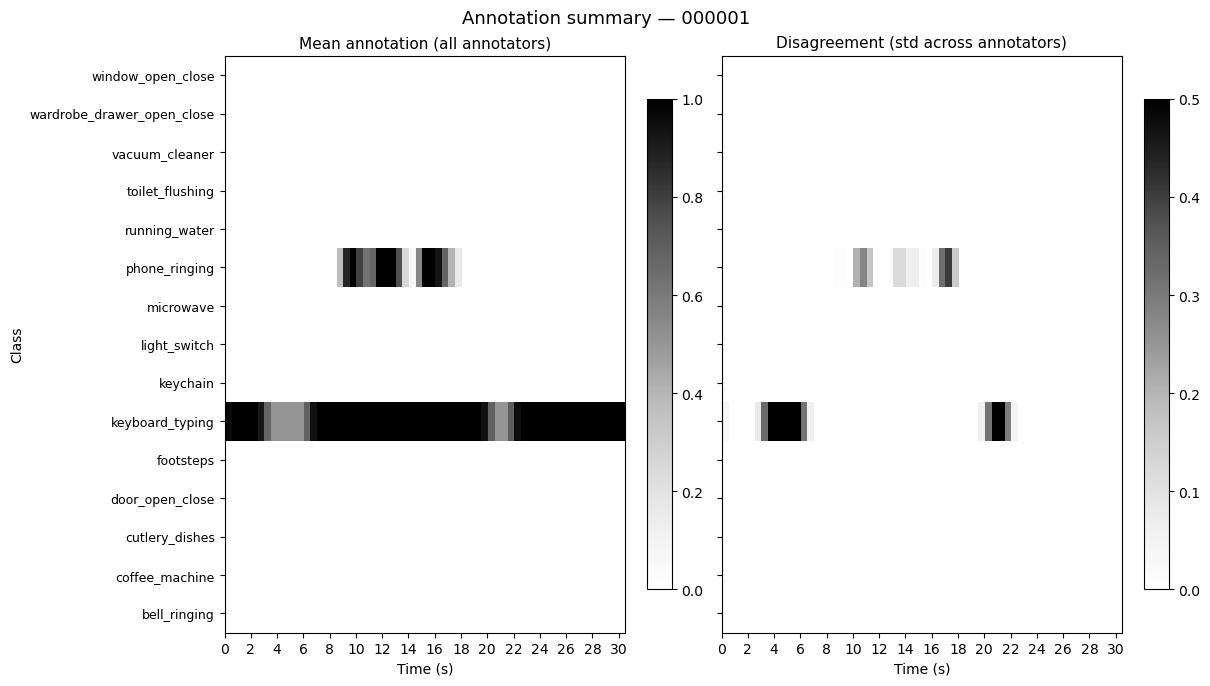

In [33]:
# Mean annotation & inter-annotator disagreement (std)
ann_mean = ann.mean(axis=2)   # [T, C]
ann_std  = ann.std(axis=2)    # [T, C]

fig, axes = plt.subplots(1, 2, figsize=(12, max(3, C * 0.45)), sharey=True, constrained_layout=True)

for ax, matrix, title in zip(
    axes,
    [ann_mean, ann_std],
    ["Mean annotation (all annotators)", "Disagreement (std across annotators)"],
):
    im = ax.imshow(
        matrix.T,
        aspect="auto",
        origin="lower",
        vmin=0, vmax=matrix.max() or 1,
        cmap="Greys",
        extent=[0, T * hop, -0.5, C - 0.5],
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_yticks(range(C))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    fig.colorbar(im, ax=ax, shrink=0.85)

axes[0].set_yticklabels(class_names, fontsize=9)
axes[0].set_ylabel("Class")
fig.suptitle(f"Annotation summary — {example_file_id}", fontsize=13)
plt.show()

## 7. Class Prevalence

How active is each class on average? We aggregate the annotation array over time and annotators - using `np.nanmean` to ignore annotators who did not annotate a given file.

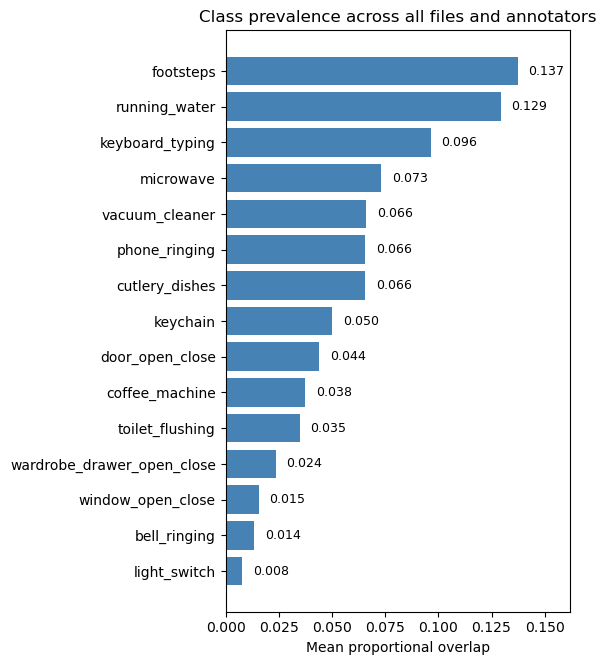

In [34]:
# Collect annotation arrays across all files
all_ann_flat = []   # list of [T*A, C] arrays (one per file)

for file_id in feature_file_map:
    d = load_feature_file(file_id)
    if "annotations" not in d:
        continue
    ann = d["annotations"].astype(float)   # [T, C, A]
    T, C, A = ann.shape
    all_ann_flat.append(ann.transpose(0, 2, 1).reshape(-1, C))   # [T*A, C]

stacked    = np.concatenate(all_ann_flat, axis=0)   # [N, C]
prevalence = np.nanmean(stacked, axis=0)             # [C]

# Class names
class_names = sorted(annotations["annotation"].unique().tolist())
if len(class_names) != len(prevalence):
    class_names = [f"Class {i}" for i in range(len(prevalence))]

# Sort bars by prevalence (highest first)
order = np.argsort(prevalence)[::-1]
sorted_prev = prevalence[order]
sorted_names = [class_names[i] for i in order]

fig, ax = plt.subplots(figsize=(6, max(4, len(class_names) * 0.45)))
ax.barh(range(len(sorted_prev)), sorted_prev, color="steelblue")
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()
ax.set_xlabel("Mean proportional overlap")
ax.set_xlim(0, sorted_prev.max() * 1.18)
ax.set_title("Class prevalence across all files and annotators")
for i, v in enumerate(sorted_prev):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Annotator Agreement

One way to measure the agreement between annotators is using the **Jaccard similarity** between the sets of active annotations:

$$J = \frac{|\text{all annotators active}|}{|\text{at least one annotator active}|} = \frac{\text{intersection}}{\text{union}}$$

It is defined as the Intersection over Union (IoU).
Here, only cells where at least one annotator marked something active are considered. A value of 1 means all annotators agreed on every active event; 0 means no overlap at all.

In [35]:
agreement_rates = []
agreement_mean_std = {}
class_idx = 0
for idx in range(15):
    class_idx = idx
    for file_id in feature_file_map:
        d = load_feature_file(file_id)
        if "annotations" not in d or d["annotations"].shape[2] < 2:
            continue
        
        binary = d["annotations"] > 0             # [T, C, A]
        class_data = binary[:, class_idx, :]

        intersection = class_data.all(axis=1).sum()   # cells all annotators marked active
        union = class_data.any(axis=1).sum()   # cells at least one annotator marked active
        if union == 0:
            continue
        agreement_rates.append(intersection / union)

    agreement_rates = np.array(agreement_rates)
    print(f"Class: {class_names[class_idx]}")
    print(f"Jaccard agreement (intersection / union of active cells)")
    print(f"  Mean  : {agreement_rates.mean():.1%}")
    print(f"  Std   : {agreement_rates.std():.1%}")
    #print(f"  Min   : {agreement_rates.min():.1%}")
    #print(f"  Max   : {agreement_rates.max():.1%}")
    agreement_mean_std[class_names[idx]] = (agreement_rates.mean(), agreement_rates.std())
    agreement_rates = []

Class: bell_ringing
Jaccard agreement (intersection / union of active cells)
  Mean  : 71.1%
  Std   : 31.4%
Class: coffee_machine
Jaccard agreement (intersection / union of active cells)
  Mean  : 76.0%
  Std   : 32.1%
Class: cutlery_dishes
Jaccard agreement (intersection / union of active cells)
  Mean  : 64.7%
  Std   : 32.7%
Class: door_open_close
Jaccard agreement (intersection / union of active cells)
  Mean  : 53.4%
  Std   : 32.7%
Class: footsteps
Jaccard agreement (intersection / union of active cells)
  Mean  : 53.6%
  Std   : 34.8%
Class: keyboard_typing
Jaccard agreement (intersection / union of active cells)
  Mean  : 82.4%
  Std   : 25.1%
Class: keychain
Jaccard agreement (intersection / union of active cells)
  Mean  : 67.7%
  Std   : 29.1%
Class: light_switch
Jaccard agreement (intersection / union of active cells)
  Mean  : 60.5%
  Std   : 37.1%
Class: microwave
Jaccard agreement (intersection / union of active cells)
  Mean  : 74.4%
  Std   : 32.4%
Class: phone_ringin

In [36]:
for k, v in agreement_mean_std.items():
    print(k, type(v[0]), type(v[1]))

bell_ringing <class 'numpy.float64'> <class 'numpy.float64'>
coffee_machine <class 'numpy.float64'> <class 'numpy.float64'>
cutlery_dishes <class 'numpy.float64'> <class 'numpy.float64'>
door_open_close <class 'numpy.float64'> <class 'numpy.float64'>
footsteps <class 'numpy.float64'> <class 'numpy.float64'>
keyboard_typing <class 'numpy.float64'> <class 'numpy.float64'>
keychain <class 'numpy.float64'> <class 'numpy.float64'>
light_switch <class 'numpy.float64'> <class 'numpy.float64'>
microwave <class 'numpy.float64'> <class 'numpy.float64'>
phone_ringing <class 'numpy.float64'> <class 'numpy.float64'>
running_water <class 'numpy.float64'> <class 'numpy.float64'>
toilet_flushing <class 'numpy.float64'> <class 'numpy.float64'>
vacuum_cleaner <class 'numpy.float64'> <class 'numpy.float64'>
wardrobe_drawer_open_close <class 'numpy.float64'> <class 'numpy.float64'>
window_open_close <class 'numpy.float64'> <class 'numpy.float64'>


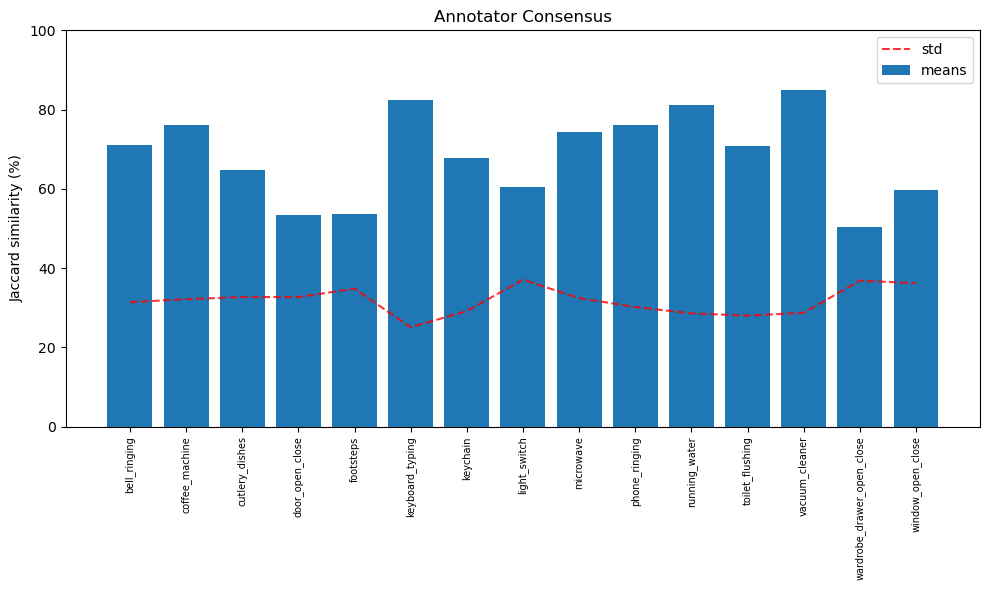

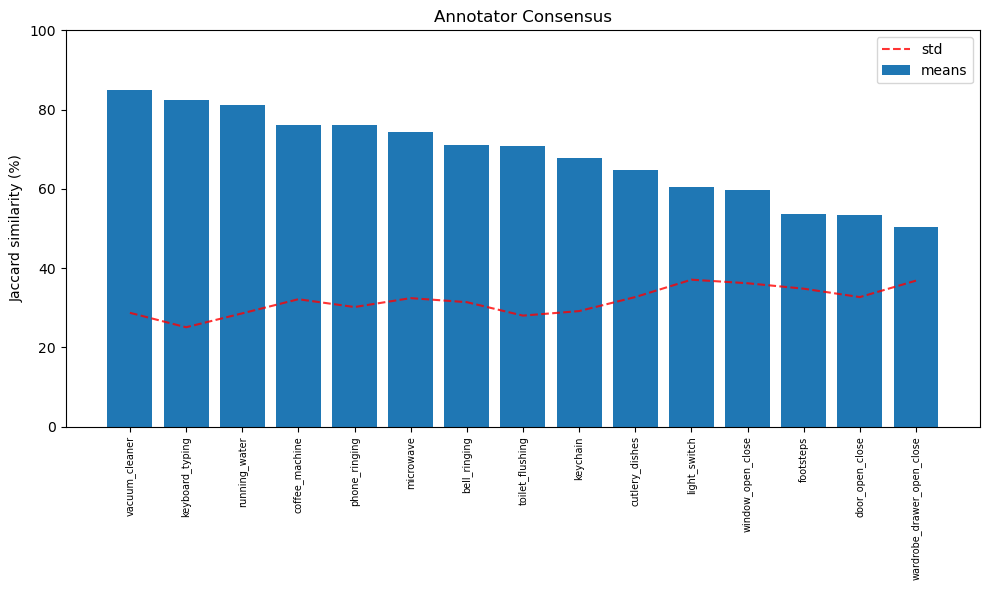

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

classes = list(agreement_mean_std.keys())
means = [v[0]*100 for v in agreement_mean_std.values()]
stds = [v[1]*100 for v in agreement_mean_std.values()]

ax.bar(classes, means, label="means")

ax.plot(classes, stds, color="red", linestyle="--", alpha=0.8, label="std")

ax.set_title("Annotator Consensus")
ax.set_ylabel("Jaccard similarity (%)")
ax.set_ylim(0, 100)


plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.legend()

plt.savefig("agreement_plot.png", dpi=300)

plt.show()

#-------------------------------------------------------------------------------------
# additional plot sorted by agreement mean

fig, ax = plt.subplots(figsize=(10, 6))

classes = list(agreement_mean_std.keys())
means = [v[0]*100 for v in agreement_mean_std.values()]
stds = [v[1]*100 for v in agreement_mean_std.values()]

# Sort classes by their agreement means
means, classes, stds = zip(*sorted(zip(means, classes, stds), reverse=True))

ax.bar(classes, means, label="means")
ax.plot(classes, stds, color="red", linestyle="--", alpha=0.8, label="std")
ax.set_title("Annotator Consensus")
ax.set_ylabel("Jaccard similarity (%)")
ax.set_ylim(0, 100)


plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.legend()

plt.savefig("agreement_plot_sorted.png", dpi=300)

plt.show()

In [38]:
# Deciding labels for every timestep
all_files_labels = []
for file_id in feature_file_map:
    file = load_feature_file(file_id)

    n_annotators = file["is_own_recording"].shape[0]
    weights = np.ones(n_annotators)
    weights[file["is_own_recording"]] = 1.2 # Give creator a stronger vote
    weighted_votes = np.tensordot(file["annotations"], weights, axes=(2, 0)) / weights.sum()
    
    labels = (weighted_votes > 0.5).astype(int)

    all_files_labels.append(labels)


In [39]:
# Lets make this list an array so we can work with it
max_T = max(arr.shape[0] for arr in all_files_labels)
n_classes = 15

padded_labels = np.zeros((len(all_files_labels), max_T, n_classes), dtype=int)

for i, arr in enumerate(all_files_labels):
    T = arr.shape[0]
    padded_labels[i, :T, :] = arr

print(padded_labels.shape)
print(padded_labels[:1,:1,:])

(3656, 78, 15)
[[[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]]]


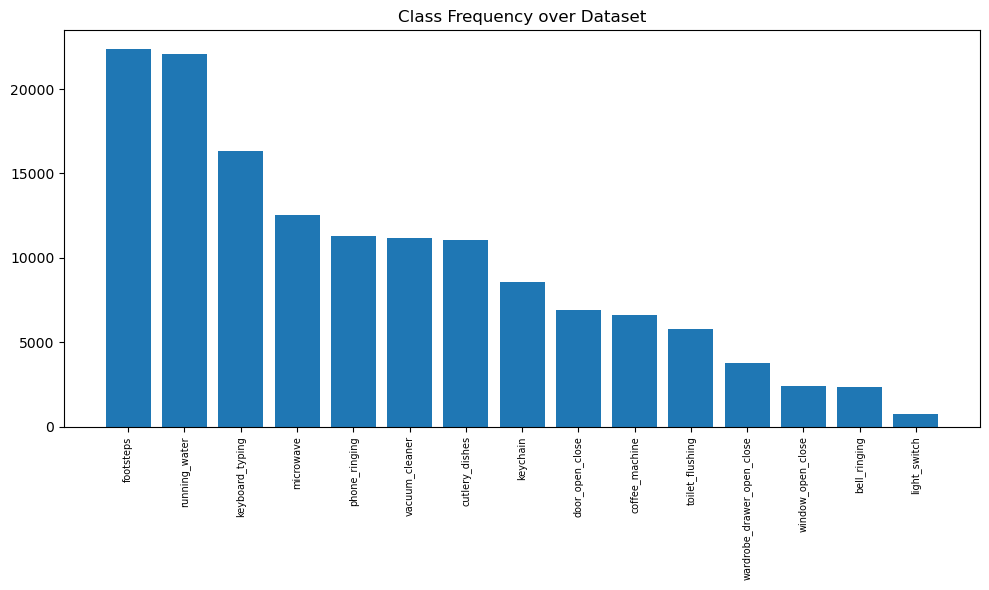

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

class_names = np.array(class_names)

total_per_class = padded_labels.sum(axis=(0,1))
sorted_totals = np.argsort(-total_per_class)



ax.bar(class_names[sorted_totals], total_per_class[sorted_totals])

ax.set_title("Class Frequency over Dataset")
plt.xticks(rotation=90, fontsize=7)

plt.tight_layout()

plt.savefig("class_occurences_over_data.png", dpi=300)
plt.show()

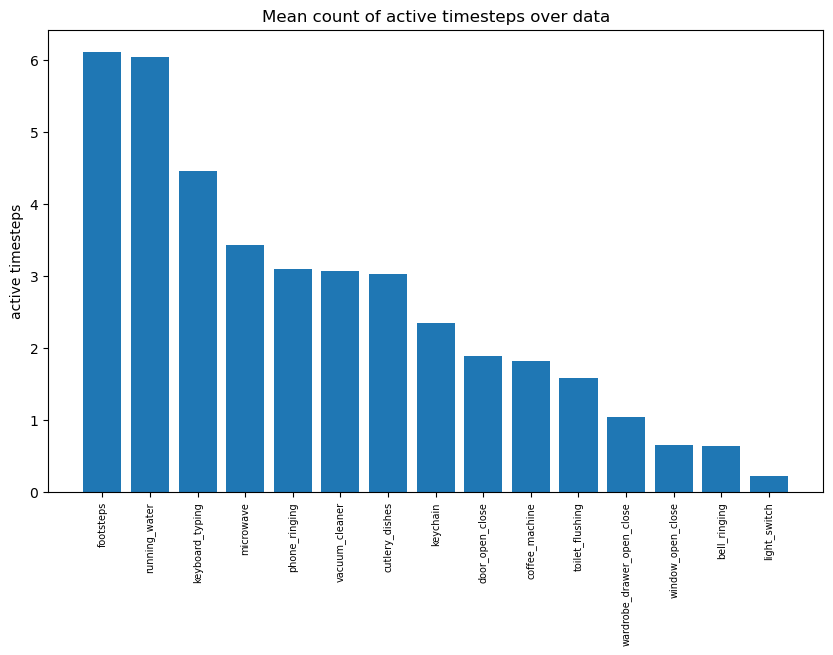

In [41]:
# Count active timesteps per file and class
timesteps_per_file_class = padded_labels.sum(axis=1)
mean_t = timesteps_per_file_class.mean(axis=0)

sorted_mean_t = np.argsort(-mean_t)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(class_names[sorted_mean_t], mean_t[sorted_mean_t])

ax.set_title("Mean count of active timesteps over data")
ax.set_ylabel("active timesteps")

plt.xticks(rotation=90, fontsize=7)
plt.show()

In [42]:
def count_segments(binary_array):
    return np.sum((binary_array[1:] == 1) & (binary_array[:-1] == 0)) + (binary_array[0] == 1)

segment_counts = []

for labels in all_files_labels:
    counts_per_class = [
        count_segments(labels[:, c]) for c in range(labels.shape[1])
    ]
    segment_counts.append(counts_per_class)

segment_counts = np.array(segment_counts)

mean_segments_per_class = segment_counts.mean(axis=0)
avg_segment_length = mean_t / mean_segments_per_class

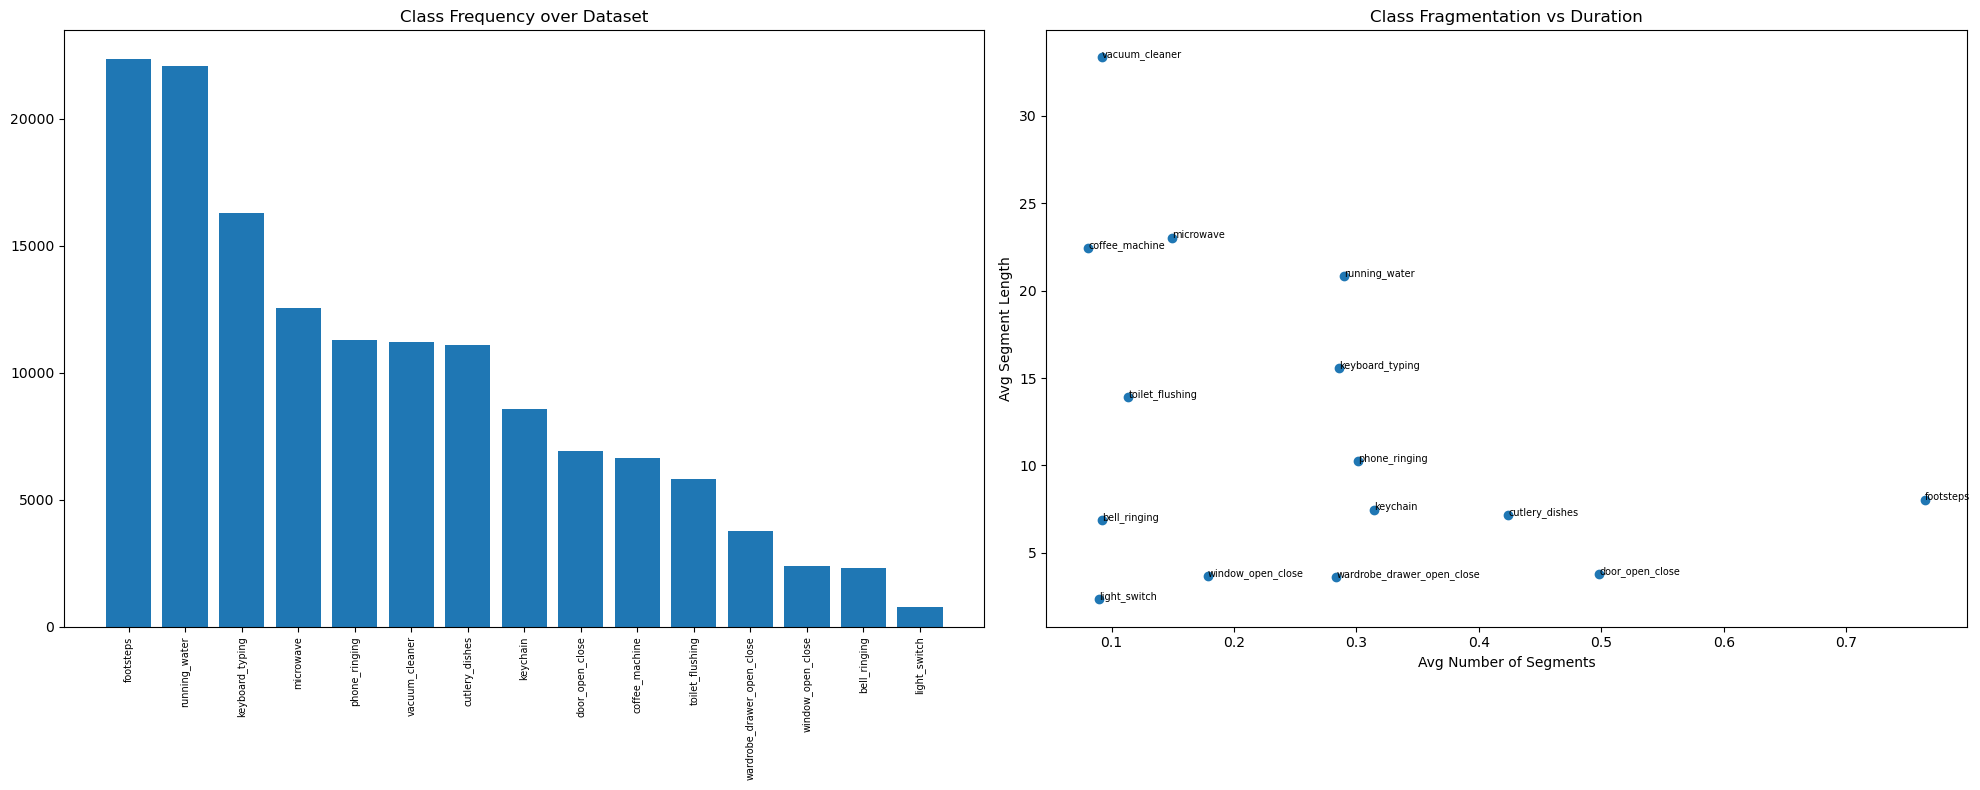

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax = ax.flatten()

ax[0].bar(class_names[sorted_totals], total_per_class[sorted_totals])
ax[0].set_title("Class Frequency over Dataset")
ax[0].tick_params(axis="x", rotation=90, labelsize=7)

ax[1].scatter(mean_segments_per_class, avg_segment_length)

for i, name in enumerate(class_names):
    ax[1].annotate(name, (mean_segments_per_class[i], avg_segment_length[i]), fontsize=7)

ax[1].set_xlabel("Avg Number of Segments")
ax[1].set_ylabel("Avg Segment Length")
ax[1].set_title("Class Fragmentation vs Duration")

plt.tight_layout()
plt.savefig("Class Distribution Analysis", dpi=300)

plt.show()

## Dimensionality Reduction
-> PCA
-> T-sne
-> UMAP

In [44]:
# For a PCA we want to find the principal components which demonstrate the largest variance in a 2D dataset. 
# Therefore we need to reduce our features which themselves have a higher dimensionality into scalar values first.
# Also we want to reduce highly correlated features to avoid unnecessary computations.
# For this reason and by learning from the correlation matrix we chose the following features to keep:

feature_cols = [
    "zcr_mean", "zcr_std", "zcr_min", "zcr_max",
    "mfcc_mean", "mfcc_std", "mfcc_min", "mfcc_max",
    "mfcc_d_mean", "mfcc_d_std", "mfcc_d_min", "mfcc_d_max",
    "mfcc_d2_mean", "mfcc_d2_std", "mfcc_d2_min", "mfcc_d2_max",
    "contrast_mean", "contrast_std", "contrast_min", "contrast_max",
    "power_mean", "power_std", "power_min", "power_max"
]

# Now reduce all of these to scalars per sample. i.e. take the mean per timestep and then the mean of the sample
# We also have to find a way to filter the samples. 3096 data points in such closely correlated data are too many.

scalar_matrix = []
final_labels = []

for i, ex in enumerate(feature_file_map):
    data = load_feature_file(ex)
    row = []

    # The idea to filter out more difficult data is to ignore segments with more than one active class at a time as well as those without active targets
    labels = all_files_labels[i]
    mask = labels.sum(axis=1) == 1

    # save case:
    if mask.sum() == 0:
        continue

    for feature in feature_cols:
        arr = data[feature]
        arr = arr[mask]

        if arr.ndim > 1 and arr.shape[1] > 1:
            arr = arr.mean(axis=1)
        
        scalar_value = arr.mean()
        row.append(scalar_value)

    scalar_matrix.append(row)

    # extract labels
    clean_labels = labels[mask]
    class_idx = np.argmax(clean_labels, axis=1)
    final_label = np.bincount(class_idx).argmax()
    final_labels.append(final_label)

scalar_array = np.array(scalar_matrix)
label_array = np.array(final_labels)

print(scalar_array.shape)
print(label_array.shape)

(3635, 24)
(3635,)


In [45]:
all_files_labels[1].shape

(59, 15)

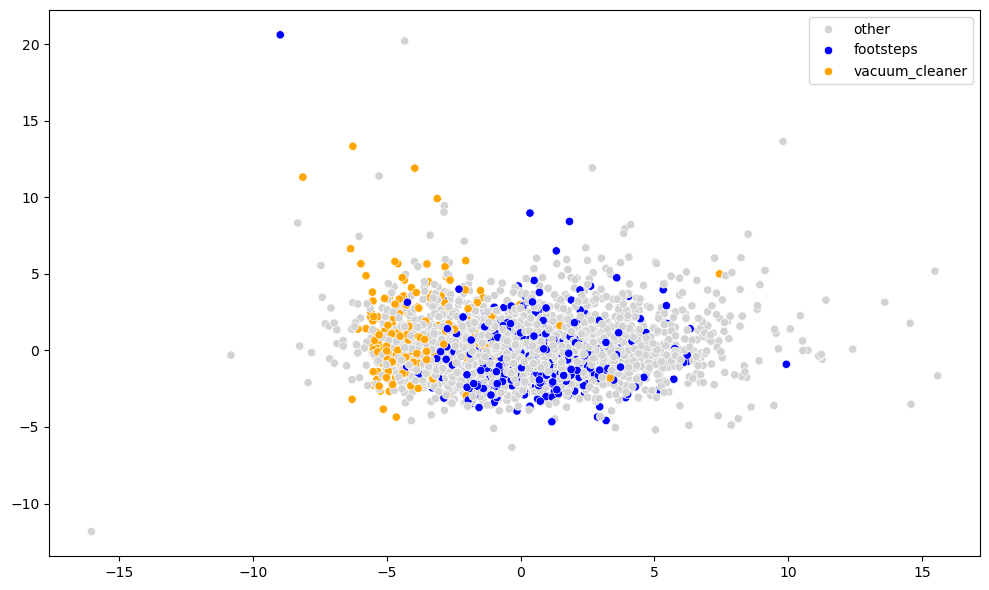

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(scalar_array)

pca = PCA(n_components=2)
projection = pca.fit_transform(X_scaled)

label_names = [class_names[idx] for idx in label_array]
target_classes = ["footsteps", "vacuum_cleaner"]
highlighted_labels = [
    label if label in target_classes else "other"
    for label in label_names
]

palette = {
    "footsteps": "blue",
    "vacuum_cleaner": "orange",
    "other": "lightgray"
}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=projection[:, 0],
    y=projection[:, 1],
    hue=highlighted_labels,
    palette=palette
)

plt.legend()
plt.tight_layout()
plt.show()



<Axes: >

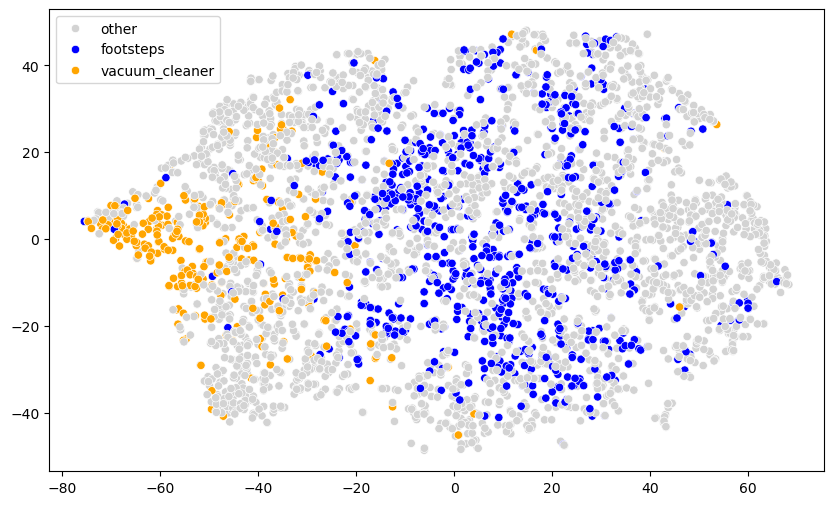

In [47]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
projection_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=projection_tsne[:, 0],
    y=projection_tsne[:, 1],
    hue=highlighted_labels,
    palette=palette
)

In [48]:
# Explore Timesteps x features instead of Samples (with collapsed timesteps) x features

feature_cols = [
    "zcr_mean", "zcr_std", "zcr_min", "zcr_max",
    "mfcc_mean", "mfcc_std", "mfcc_min", "mfcc_max",
    "mfcc_d_mean", "mfcc_d_std", "mfcc_d_min", "mfcc_d_max",
    "mfcc_d2_mean", "mfcc_d2_std", "mfcc_d2_min", "mfcc_d2_max",
    "contrast_mean", "contrast_std", "contrast_min", "contrast_max",
    "power_mean", "power_std", "power_min", "power_max"
]

all_X = []
all_y = []

for i, ex in enumerate(feature_file_map):
    data = load_feature_file(ex)

    # The idea to filter out more difficult data is to ignore segments with more than one active class at a time as well as those without active targets
    labels = all_files_labels[i]
    mask = labels.sum(axis=1) == 1

    # The next idea we have is to filter by annotator agreement.
    annotators = data["annotations"]
    agreement = annotators.mean(axis=2)
    confidence = agreement.max(axis=1)

    # Combined mask
    mask &= (confidence == 1)

    # save case:
    if mask.sum() == 0:
        continue

    feature_vectors = []

    for feature in feature_cols:
        arr = data[feature] # Just the feature vector we consider
        arr = arr[mask] # Delete every entry where not exactly 1 target class is active

        if arr.ndim > 1 and arr.shape[1] > 1:
            arr = arr.mean(axis=1)
        
        arr = arr.reshape(-1, 1) # Reshape to col vector. prepare for concatenation [T,] -> [T, 1]
        feature_vectors.append(arr)

    X_i = np.concatenate(feature_vectors, axis=1)

    # Labels per timestep
    y_i = np.argmax(labels[mask], axis=1)

    all_X.append(X_i)
    all_y.append(y_i)

# Stack all
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

label_names = [class_names[idx] for idx in y_all]
target_classes = ["footsteps", "vacuum_cleaner"]
highlighted_labels_2 = [
    label if label in target_classes else "other"
    for label in label_names
]

print(X_all.shape, y_all.shape)

(60834, 24) (60834,)


In [49]:
# Still way too many samples for a senseful tsne. Lets try with kMeans and create some clusters

from sklearn.cluster import MiniBatchKMeans

k = 5000

kmeans = MiniBatchKMeans(
    n_clusters=k,
    batch_size=10000,
    random_state=42
)

cluster_ids = kmeans.fit_predict(X_all)

selected_idx = []

for i in range(kmeans.n_clusters):
    idx = np.where(cluster_ids == i)[0]

    if len(idx) == 0:
        continue

    cluster_points = X_all[idx]
    centroid = kmeans.cluster_centers_[i]

    # distance to centroid
    dists = np.linalg.norm(cluster_points - centroid, axis=1)

    best = idx[np.argmin(dists)]
    selected_idx.append(best)

selected_idx = np.array(selected_idx)

print(selected_idx.shape)

(5000,)


In [50]:
label_names = [class_names[idx] for idx in y_all[selected_idx]]
target_classes = ["footsteps", "vacuum_cleaner"]
highlighted_labels_2 = [
    label if label in target_classes else "other"
    for label in label_names
]

<Axes: >

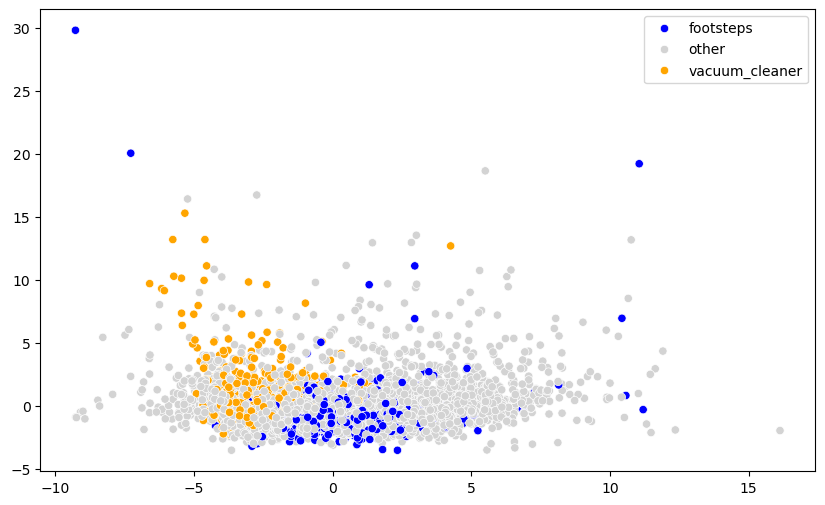

In [51]:
# PCA 2 with timesteps kept

scaler_2 = StandardScaler()
X_scaled_2 = scaler_2.fit_transform(X_all)

pca_2 = PCA(n_components=2, random_state=42)
projection_pca_2 = pca_2.fit_transform(X_scaled_2[selected_idx])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=projection_pca_2[:, 0],
    y=projection_pca_2[:, 1],
    hue=highlighted_labels_2,
    palette=palette
)

<Axes: >

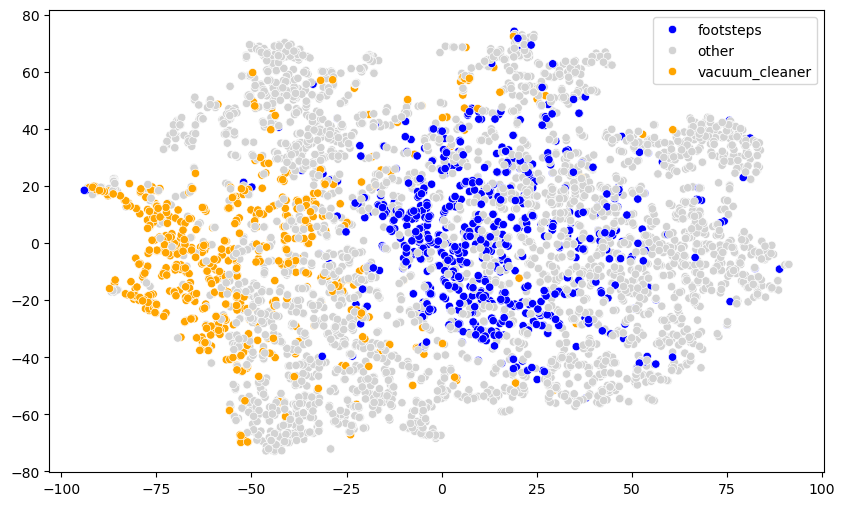

In [52]:
tsne_2 = TSNE(
    n_components=2, 
    perplexity=15, 
    #init="pca",
    random_state=42
    )

projection_tsne_2 = tsne_2.fit_transform(X_scaled_2[selected_idx])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=projection_tsne_2[:, 0],
    y=projection_tsne_2[:, 1],
    hue=highlighted_labels_2,
    palette=palette
)

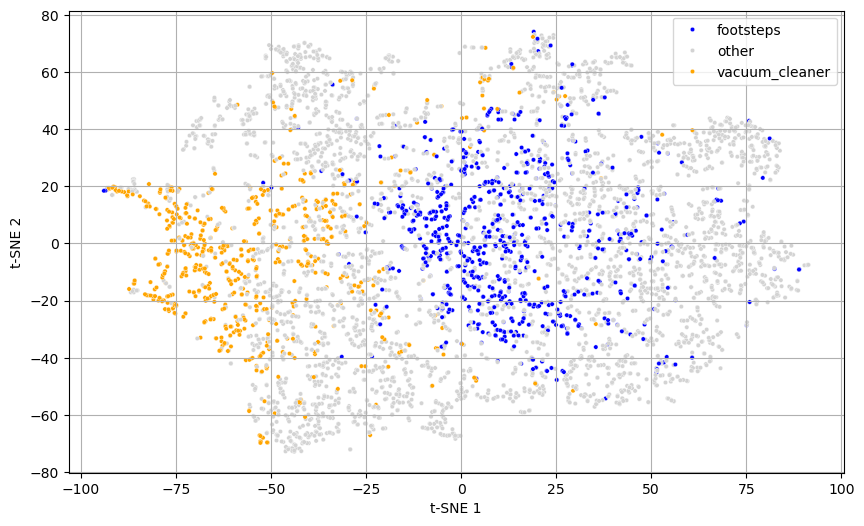

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=projection_tsne_2[:, 0],
    y=projection_tsne_2[:, 1],
    hue=highlighted_labels_2,
    palette=palette,
    s=10
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid()

plt.savefig("t-SNE downprojection.png", dpi=300)

## Audio Features — Task 3.a: Metadata Distribution

We inspect three recording properties from `metadata.csv`: device placement, recording device, and recording environment.

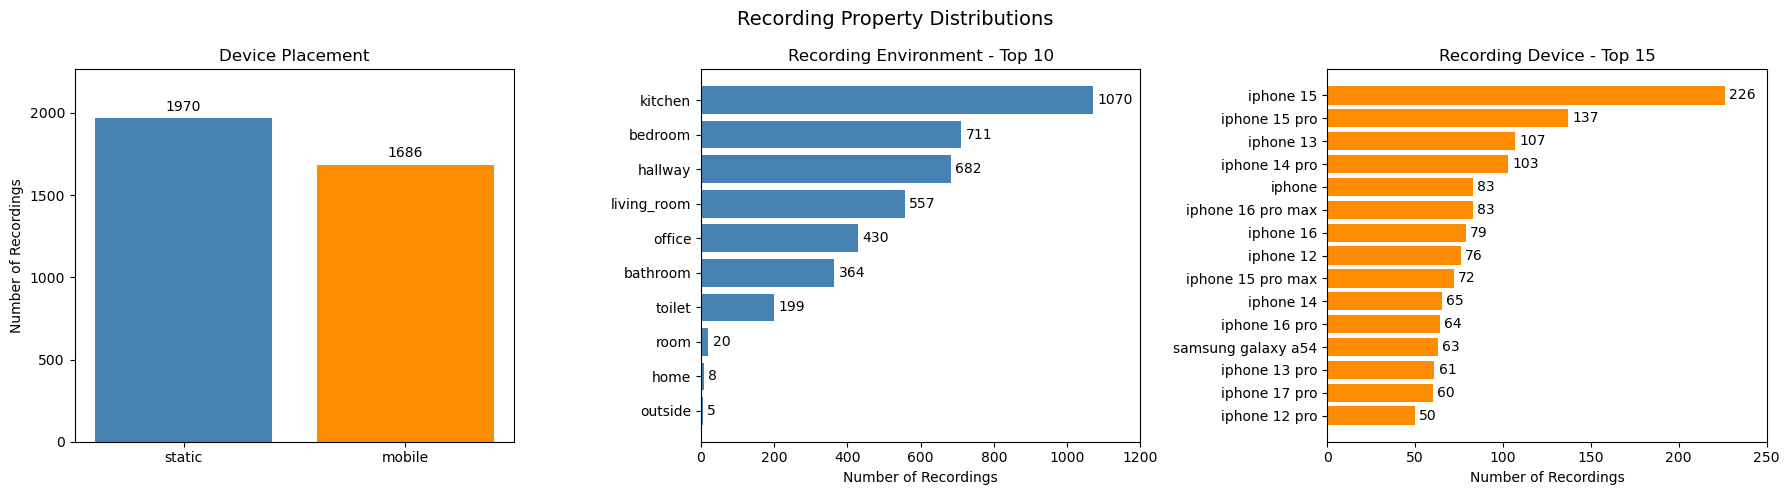


Unique recording devices (after normalization): 299

--- iPhone vs Others ---
iPhones (any model): 1859 (50.8%)
Other devices:       1797 (49.2%)


In [54]:
metadata = pd.read_csv(os.path.join(PATH_TO_DATASET, "metadata.csv"))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Recording Property Distributions", fontsize=14)

# device placement
ax = axes[0]
placement_counts = metadata["device_placement"].value_counts()
bars = ax.bar(placement_counts.index, placement_counts.values, color=["steelblue", "darkorange"])
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_title("Device Placement")
ax.set_ylabel("Number of Recordings")
ax.set_ylim(0, placement_counts.max() * 1.15)

# recording environment (top 10)
ax = axes[1]

# prepare data for plotting
env_counts = (
    metadata["recording_environment"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
    .sort_values() # sort ascending
)

# plot bars
bars = ax.barh(env_counts.index, env_counts.values, color="steelblue")
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_title("Recording Environment - Top 10")
ax.set_xlabel("Number of Recordings")
ax.set_xlim(0, 1200)

# recording device (top 15)
ax = axes[2]

device_norm = metadata["recording_device"].str.strip().str.lower() # normalize device names - strip whitespace, lowercase for grouping
device_counts = device_norm.value_counts().head(15).sort_values() # sort ascending for horizontal bar plot

bars = ax.barh(device_counts.index, device_counts.values, color="darkorange")
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_title("Recording Device - Top 15")
ax.set_xlabel("Number of Recordings")
ax.set_xlim(0, 250)

plt.tight_layout()
plt.savefig("metadata_distribution.png", dpi=300, bbox_inches="tight") # save high-res version for report
plt.show()

print(f"\nUnique recording devices (after normalization): {device_norm.nunique()}")

# calculate iPhone percentage
iphone_mask = device_norm.str.contains("iphone", na=False)
iphone_count = iphone_mask.sum()
total_devices = len(device_norm)
iphone_pct = (iphone_count / total_devices) * 100

print(f"\n--- iPhone vs Others ---")
print(f"iPhones (any model): {iphone_count} ({iphone_pct:.1f}%)")
print(f"Other devices:       {total_devices - iphone_count} ({100 - iphone_pct:.1f}%)")

## Audio Features — Task 3.b: Feature Statistics

We load all `.npz` files, concatenate the `*_mean` aggregation for each scalar feature group, and compute global **mean**, **standard deviation**, **min**, and **max** across all segments and all recordings. 

Multi-dimensional features (Mel spectrogram, MFCCs, etc.) would need to be summarised by averaging across their feature dimension first, and are therefore skipped in this step.

In [55]:
features_dir = os.path.join(PATH_TO_DATASET, "audio_features")
npz_files = sorted([f for f in os.listdir(features_dir) if f.endswith(".npz")])

SCALAR_FEATURES = ["zcr", "flux", "flatness", "centroid", "bandwidth","rolloff_low", "rolloff_high", "energy", "power"]

accum = {f: [] for f in SCALAR_FEATURES} # dict to accumulate per-segment values across files

for fname in npz_files:
    data = dict(np.load(os.path.join(features_dir, fname), allow_pickle=True))
    for feat in SCALAR_FEATURES:
        key = feat + "_mean"
        if key in data:
            accum[feat].append(data[key].reshape(-1))   # flatten to (T,)

# concatenate and compute statistics
rows = []
for feat in SCALAR_FEATURES:
    vals = np.concatenate(accum[feat]) if accum[feat] else np.array([np.nan])
    rows.append({
        "Feature": feat,
        "Mean":  np.mean(vals),
        "Std":   np.std(vals),
        "Min":   np.min(vals),
        "Max":   np.max(vals),
    })

stats_df = pd.DataFrame(rows).set_index("Feature")
display(stats_df)

# generate latex table code for report
latex_code = stats_df.to_latex(
    column_format="lrrrr",  
    caption="Summary statistics of extracted scalar audio features",
    label="tab:feature_stats",
    position="h",
    escape=False,
    float_format="%.3f"       
)

print(latex_code)

,Mean,Std,Min,Max
Feature,,,,
zcr,0.191428,0.132559,0.000000,0.813340
flux,1.952641,2.549809,0.000000,49.974545
flatness,0.088426,0.086705,0.000001,1.000001
centroid,2207.009413,884.198620,0.000000,5788.951694
bandwidth,2784.847200,518.917377,0.000000,4359.974387
rolloff_low,299.441496,321.523878,0.000000,3787.187500
rolloff_high,5073.701405,1327.630342,0.000000,7514.687500
energy,31.683754,46.224960,0.000000,615.891724
power,63.393078,204.084396,0.000000,11140.391602


\begin{table}[h]
\caption{Summary statistics of extracted scalar audio features}
\label{tab:feature_stats}
\begin{tabular}{lrrrr}
\toprule
 & Mean & Std & Min & Max \\
Feature &  &  &  &  \\
\midrule
zcr & 0.191 & 0.133 & 0.000 & 0.813 \\
flux & 1.953 & 2.550 & 0.000 & 49.975 \\
flatness & 0.088 & 0.087 & 0.000 & 1.000 \\
centroid & 2207.009 & 884.199 & 0.000 & 5788.952 \\
bandwidth & 2784.847 & 518.917 & 0.000 & 4359.974 \\
rolloff_low & 299.441 & 321.524 & 0.000 & 3787.188 \\
rolloff_high & 5073.701 & 1327.630 & 0.000 & 7514.688 \\
energy & 31.684 & 46.225 & 0.000 & 615.892 \\
power & 63.393 & 204.084 & 0.000 & 11140.392 \\
\bottomrule
\end{tabular}
\end{table}



## Audio Features — Task 3.c: Feature Correlation

We analyse which feature categories are correlated with each other. We pool all time segments across all recordings into a single table, where each **row is one time segment** and each **column is one feature category** (multi-dimensional features such as MFCCs or Mel-spectrograms are reduced to a scalar by averaging over their feature dimension). We then compute the **Pearson correlation matrix** between columns — quantifying how strongly two feature categories co-vary across segments.

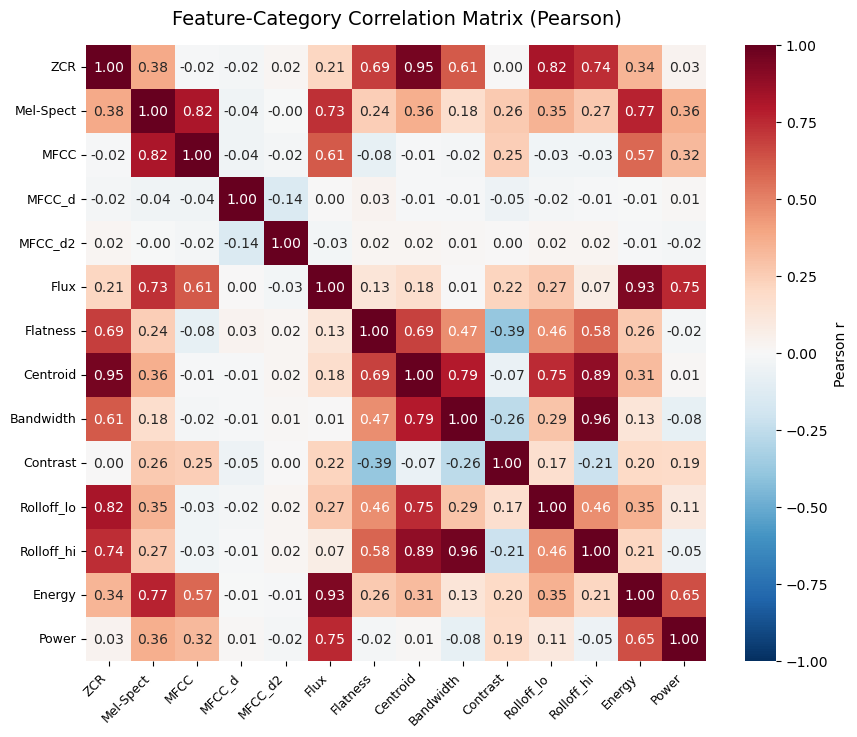

Strongest inter-category correlations (|r| > 0.85):


,Feature 1,Feature 2,Correlation
123,Bandwidth,Rolloff_hi,0.964671
98,Centroid,ZCR,0.954455
173,Energy,Flux,0.934963
109,Centroid,Rolloff_hi,0.888724


In [56]:
features_dir = os.path.join(PATH_TO_DATASET, "audio_features")
npz_files = sorted([f for f in os.listdir(features_dir) if f.endswith(".npz")])

# feature categories and their representative scalar (mean over feature dim)
CATEGORIES = {
    "ZCR":        "zcr_mean",
    "Mel-Spect":  "melspect_mean",
    "MFCC":       "mfcc_mean",
    "MFCC_d":     "mfcc_d_mean",
    "MFCC_d2":    "mfcc_d2_mean",
    "Flux":       "flux_mean",
    "Flatness":   "flatness_mean",
    "Centroid":   "centroid_mean",
    "Bandwidth":  "bandwidth_mean",
    "Contrast":   "contrast_mean",
    "Rolloff_lo": "rolloff_low_mean",
    "Rolloff_hi": "rolloff_high_mean",
    "Energy":     "energy_mean",
    "Power":      "power_mean",
}

# create (n_segments, n_categories) matrix
cat_vectors = {name: [] for name in CATEGORIES}

for fname in npz_files:
    data = dict(np.load(os.path.join(features_dir, fname), allow_pickle=True))
    n_seg = data["zcr_mean"].shape[0] # nr. of segments in this file

    for name, key in CATEGORIES.items(): # get category key value pairs as tuples
        if key in data:
            arr = data[key]                       # (T,) or (T, D)
            if arr.ndim > 1:
                arr = arr.mean(axis=-1)           # summarise to (T,) / mean over feature dim
            cat_vectors[name].append(arr)         # append to list for this category
        else:
            cat_vectors[name].append(np.full(n_seg, np.nan)) # if missing, fill with NaN to keep alignment

# stack into matrix
mat = {}
for name in CATEGORIES:
    mat[name] = np.concatenate(cat_vectors[name])

# convert to dataframe and calculate pearson correlation matrix
df_cats = pd.DataFrame(mat)
df_cats.dropna(inplace=True)
corr = df_cats.corr(method="pearson") 

# visualize with seaborn heatmap
plt.figure(figsize=(10, 8))
plt.title("Feature-Category Correlation Matrix (Pearson)", fontsize=14, pad=15)
sns.heatmap(
    corr, 
    annot=True,          
    fmt=".2f",           
    cmap="RdBu_r",       
    vmin=-1, vmax=1,     
    cbar_kws={'label': 'Pearson r'}
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)

plt.savefig("feature_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# print strongest correlations
df_corr = corr.stack().reset_index() #flatten matrix into normal DataFrame
df_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
strong = df_corr[(df_corr['Correlation'].abs() > 0.85) & (df_corr['Feature 1'] < df_corr['Feature 2'])]
strong = strong.sort_values(by='Correlation', key=abs, ascending=False)
print("Strongest inter-category correlations (|r| > 0.85):")
display(strong)


## 9. Audio Feature Visualizations

Each `.npz` file contains pre-computed features extracted on **32 ms frames** and then aggregated over **1 s windows** (hop = 0.5 s). For each feature type four aggregation statistics are stored: `*_mean`, `*_std`, `*_min`, `*_max`.

Available features: `zcr`, `melspect`, `mfcc`, `mfcc_d`, `mfcc_d2`, `flux`, `flatness`, `centroid`, `bandwidth`, `contrast`, `rolloff_low`, `rolloff_high`, `energy`, `power`.

### Feature matrix (mel spectrogram)

`melspect_mean` gives the mean mel-band energy per window - analogous to a standard mel spectrogram, but at 0.5 s resolution.

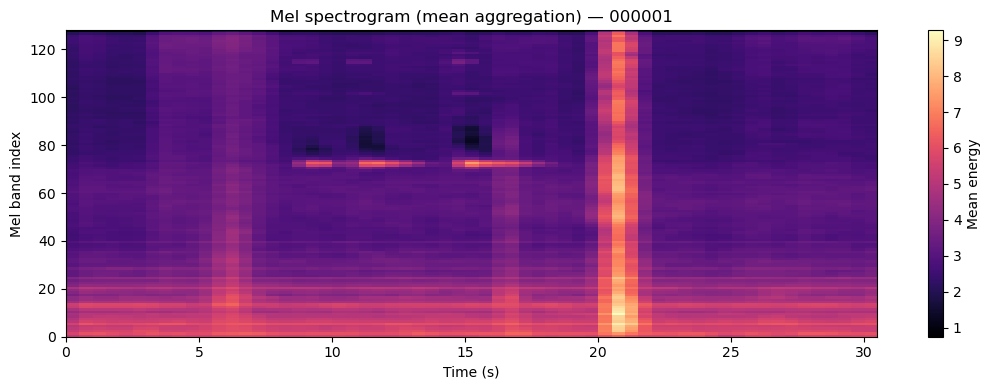

In [57]:
data = dict(load_feature_file(example_file_id))
hop  = 0.5   # seconds

melspect = data["melspect_mean"]   # [T, n_mels]
T_mel = melspect.shape[0]

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(
    melspect.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[0, T_mel * hop, 0, melspect.shape[1]],
    cmap="magma",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mel band index")
ax.set_title(f"Mel spectrogram (mean aggregation) — {example_file_id}")
fig.colorbar(im, ax=ax, label="Mean energy")
plt.tight_layout()
plt.show()

## 10. Raw Audio Waveforms

Instead of (pre-computed) audio features, we can also have a look at the raw audio waveforms. For this, the ```librosa``` library can be helpful.

Before we can load the files, make sure to download the ```MLPC2026_dataset_development_raw_audio.zip``` file and extract it, which should give you the following:
```
MLPC2026_dataset_development_raw_audio       <-- load this
|-- 000001.wav
|-- 000002.wav
\-- ...
```

Now, set the path to the raw audio files:

In [58]:
PATH_TO_AUDIO = 'MLPC2026_dataset_development_raw_audio'

We can load the audio files with ```librosa.load``` as follows:

In [59]:
import os
import librosa
import numpy as np

wav_files = sorted(
    [f for f in os.listdir(PATH_TO_AUDIO) if f.endswith(".wav")]
 )

print(f"Found {len(wav_files)} audio files in {PATH_TO_AUDIO}")
print("First 5 files:", wav_files[:5])

# Map from stem (e.g., '000001') to absolute file path again for quick lookup, as for features
audio_file_map = {
    os.path.splitext(filename)[0]: os.path.join(PATH_TO_AUDIO, filename)
    for filename in wav_files
}

def load_audio_file(file_id: str, sr: int = 22050):
    """Lazy-load a single .wav file by ID (without .wav extension)."""
    path = audio_file_map[file_id]
    y, sr = librosa.load(path, sr=sr)
    return y, sr

# Load one exemplary audio file
example_file_id = next(iter(audio_file_map))
example_audio, sr = load_audio_file(example_file_id)

FileNotFoundError: [Errno 2] No such file or directory: 'MLPC2026_dataset_development_raw_audio'

The result of ```librosa.load``` is a ```numpy``` array. 
We here loaded the files with a sampling rate of 22050 (```sr = None``` loads the audio file with its original sampling rate). 

Let us look at the shape of the audio file; because we look at mono signals here, it is a one dimensional array. The length depends on the length of the audio and the sampling rate:

In [ ]:
print(example_audio.shape)

(688196,)


### Raw Audio Visualization

We can also use ```librosa``` to visualize the waveform, e.g.:

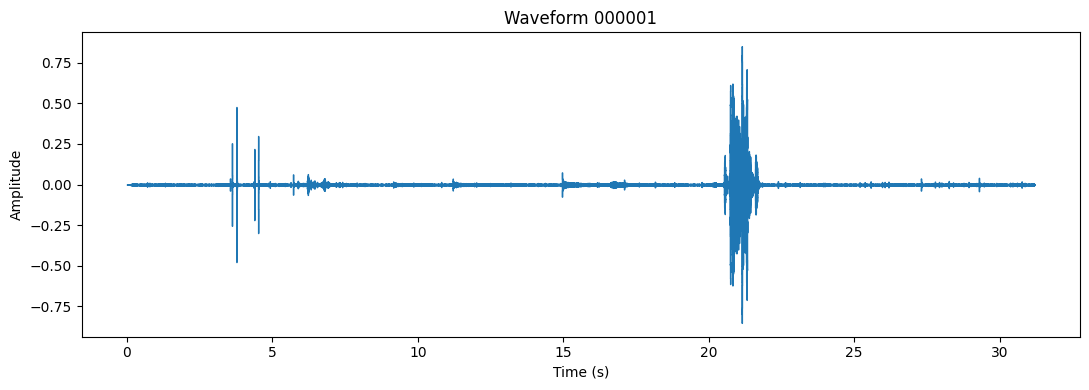

In [ ]:
import matplotlib.pyplot as plt

# First, load exemplary audio file
y, sr = load_audio_file(example_file_id)

# Now use matplotlib and ```librosa.display.waveshow``` to visualize audio content
fig, ax = plt.subplots(figsize=(11, 4))
librosa.display.waveshow(y, sr=sr, ax=ax)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Waveform {example_file_id}")
plt.tight_layout()
plt.show()